In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.pipeline.props_pipeline.apm_pipeline import apm_pipeline
from src.features.feature_engineer.apm_features import apm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
209,2025-26,201145,Jeff Green,Jeff,1610612745,HOU,Houston Rockets,22501194,2026-04-12T00:00:00,HOU vs. MEM,W,24.183333,2,8,0.250,0,4,0.00,2,2,1.000,2,3,5,1,3,1,1,0,2,1,6,7,16.5,0,0,16.0,1,24:11,1,103.9,105.5,105.5,86.1,91.1,91.1,17.8,14.4,14.4,0.059,0.33,7.7,0.063,0.100,0.081,23.1,23.3,0.250,0.338,0.174,0.181,114.13,110.16,91.80,110.16,0.016,55,2.0,8.0,48,105,0.457,14,49,0.286,22,30,0.733,21,43,64,23,11.0,10,8,6,10,24,132,31.0,122.0,128.2,94.9,98.1,27.1,30.1,0.479,2.09,14.9,0.452,0.821,0.627,0.107,0.524,0.558,107.3,103.0,85.83,103,0.642,1610612763,MEM,Memphis Grizzlies,39,95,0.411,13,49,0.265,10,10,1.000,6,31,37,23,13.0,8,6,8,24,10,101,-31.0,94.9,98.1,122.0,128.2,-27.1,-30.1,0.590,1.77,16.9,0.179,0.548,0.373,0.126,0.479,0.508,107.3,103.0,85.83,103,0.358,NaN,PF,39.0,0
210,2025-26,1631342,Daeqwon Plowden,Daeqwon,1610612758,SAC,Sacramento Kings,22501200,2026-04-12T00:00:00,SAC @ POR,L,22.200000,2,5,0.400,1,4,0.25,3,3,1.000,0,1,1,2,3,0,2,0,4,1,8,-8,15.2,0,0,16.0,1,22:12,1,118.2,114.6,114.6,127.2,134.0,134.0,-9.0,-19.5,-19.5,0.100,0.67,18.2,0.000,0.034,0.022,27.3,26.5,0.500,0.633,0.173,0.184,103.83,102.70,85.59,102.70,0.017,48,2.0,5.0,40,83,0.482,7,21,0.333,23,31,0.742,15,32,47,24,17.0,7,8,3,18,21,110,-12.0,111.5,112.2,120.1,123.2,-8.6,-11.0,0.600,1.41,17.3,0.370,0.600,0.495,0.173,0.524,0.569,100.1,98.5,82.08,98,0.478,1610612757,POR,Portland Trail Blazers,47,101,0.465,16,46,0.348,12,15,0.800,18,28,46,28,12.0,9,3,8,21,18,122,12.0,120.1,123.2,111.5,112.2,8.6,11.0,0.596,2.33,18.8,0.400,0.630,0.505,0.121,0.545,0.567,100.1,98.5,82.08,99,0.522,F,SG,27.0,1
211,2025-26,1630286,Trevon Scott,Trevon,1610612751,BKN,Brooklyn Nets,22501192,2026-04-12T00:00:00,BKN @ TOR,L,26.050000,3,8,0.375,2,5,0.40,0,0,0.000,1,2,3,1,2,1,0,0,2,0,8,-17,14.1,0,0,16.0,1,26:03,1,104.8,109.3,109.3,137.8,135.7,135.7,-32.9,-26.5,-26.5,0.053,0.50,9.1,0.038,0.125,0.071,18.2,18.2,0.500,0.500,0.164,0.161,102.67,101.34,84.45,101.34,0.027,54,3.0,8.0,35,86,0.407,9,34,0.265,22,29,0.759,13,25,38,21,16.0,9,0,8,27,20,101,-35.0,99.3,101.0,136.3,136.0,-37.1,-35.0,0.600,1.31,15.6,0.255,0.844,0.471,0.160,0.459,0.511,100.8,100.0,83.33,100,0.277,1610612761,TOR,Toronto Raptors,51,80,0.638,12,27,0.444,22,29,0.759,3,40,43,36,10.0,9,8,0,20,27,136,35.0,136.3,136.0,99.3,101.0,37.1,35.0,0.706,3.60,25.5,0.156,0.745,0.529,0.100,0.713,0.733,100.8,100.0,83.33,100,0.723,C,NaN,NaN,1
204,2025-26,1629020,Jarred Vande

In [4]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["AST_PER_MIN"] = df["AST"] / df["MIN"].replace(0, np.nan)
    df['POSS_PER_MIN'] = df['POSS'] / df['MIN'].replace(0, np.nan)
    df["TOV_PER_MIN"] = df["TOV"] / df["MIN"].replace(0, np.nan)
    df = apm_features(df)

    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TOV_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TOV_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    
    df['MEDIAN_AST_PER_MIN_L10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))


    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    # df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
    #     lambda x: x.shift(1).rolling(5, min_periods=1).std())
    df = df[df['MIN'] > 10]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.to_csv('data/processed/training/S26_TRAINING_APM.csv', index=False)

(88789, 279)


In [19]:
APM_FEATURES = [
    "MIN_10_ewm",
    "USG_PCT_10_ewm",
    "AST_PER_MIN_10_ewm",
    "AST_PCT_10_ewm",
    "TOV_PER_MIN_10_ewm",
    "AST_TO_10_ewm",
    
    "TEAM_AST_PER_MIN_RANK_L10",
    "TEAM_USG_RANK_L10",
    "TEAM_MIN_RANK_L10",

    "OPP_DEF_RATING_roll10",
    "OPP_POSS_roll10",
    "TEAM_AST_roll10",
    "PACE_DIFFERENTIAL",
    
    "ACTIVE_STARS_COUNT",
    "POSITION_ENC",
    "STARTING",
]

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = df[APM_FEATURES + ["AST_PER_MIN", "GAME_DATE"]].dropna().sort_values("GAME_DATE").reset_index(drop=True)
print(ppm_df.shape)

# ── 2. Walk-forward folds ─────────────────────────────────────────────────────
N_FOLDS   = 4
min_train = int(len(ppm_df) * 0.50)
fold_size = (len(ppm_df) - min_train) // N_FOLDS

fold_results = []

for fold in range(N_FOLDS):
    train_end = min_train + fold * fold_size
    val_end   = train_end + fold_size

    train_idx = ppm_df.index[:train_end]
    val_idx   = ppm_df.index[train_end:val_end]

    X_train_f = ppm_df.loc[train_idx, APM_FEATURES]
    X_val_f   = ppm_df.loc[val_idx,   APM_FEATURES]
    y_train_f = ppm_df.loc[train_idx, "AST_PER_MIN"]
    y_val_f   = ppm_df.loc[val_idx,   "AST_PER_MIN"]

    # ── 3. Quantile models ────────────────────────────────────────────────────
    quantiles       = [0.10, 0.50, 0.90]
    quantile_models = {}
    quantile_preds  = {}

    for q in quantiles:
        xgb_q = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=q,
            n_estimators=1378,
            max_depth=6,
            learning_rate=0.012114761889717784,
            subsample=0.658891356913107,
            colsample_bytree=0.6610449450867388,
            reg_alpha=0.35062788508631587,
            reg_lambda=0.7792871271834488,
            min_child_weight=4,
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50,
        )
        xgb_q.fit(
            X_train_f, y_train_f,
            eval_set=[(X_val_f, y_val_f)],
            verbose=False,
        )
        quantile_models[f"q_{q:.2f}"] = xgb_q
        quantile_preds[f"q_{q:.2f}"]  = xgb_q.predict(X_val_f)

    # ── 4. Fold diagnostics ───────────────────────────────────────────────────
    actual   = y_val_f.values
    lower    = quantile_preds["q_0.10"]
    median   = quantile_preds["q_0.50"]
    upper    = quantile_preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))

    fold_metrics = {
        "fold":           fold + 1,
        "train_rows":     len(train_idx),
        "val_rows":       len(val_idx),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {f"q_{q:.2f}": quantile_models[f"q_{q:.2f}"].best_iteration
                           for q in quantiles},
    }
    fold_results.append(fold_metrics)

    print(f"Fold {fold+1} | MAE: {fold_metrics['mae']:.3f} | "
          f"R²: {fold_metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%} | "
          f"Best iters: {fold_metrics['best_iters']}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
maes      = [f["mae"]            for f in fold_results]
r2s       = [f["r2"]             for f in fold_results]
coverages = [f["coverage_80pct"] for f in fold_results]

print(f"\n{'─'*55}")
print(f"Walk-Forward Summary ({N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(coverages):.1%} ± {np.std(coverages):.1%}  (target ~80%)")

(73322, 18)
Fold 1 | MAE: 0.052 | R²: 0.365 | 80% Coverage: 79.4% | Best iters: {'q_0.10': 345, 'q_0.50': 386, 'q_0.90': 471}
Fold 2 | MAE: 0.054 | R²: 0.338 | 80% Coverage: 77.7% | Best iters: {'q_0.10': 288, 'q_0.50': 552, 'q_0.90': 338}
Fold 3 | MAE: 0.053 | R²: 0.367 | 80% Coverage: 78.1% | Best iters: {'q_0.10': 380, 'q_0.50': 399, 'q_0.90': 390}
Fold 4 | MAE: 0.055 | R²: 0.339 | 80% Coverage: 77.8% | Best iters: {'q_0.10': 431, 'q_0.50': 569, 'q_0.90': 338}

───────────────────────────────────────────────────────
Walk-Forward Summary (4 folds)
  MAE      : 0.054 ± 0.001
  R²       : 0.352 ± 0.014
  Coverage : 78.3% ± 0.7%  (target ~80%)


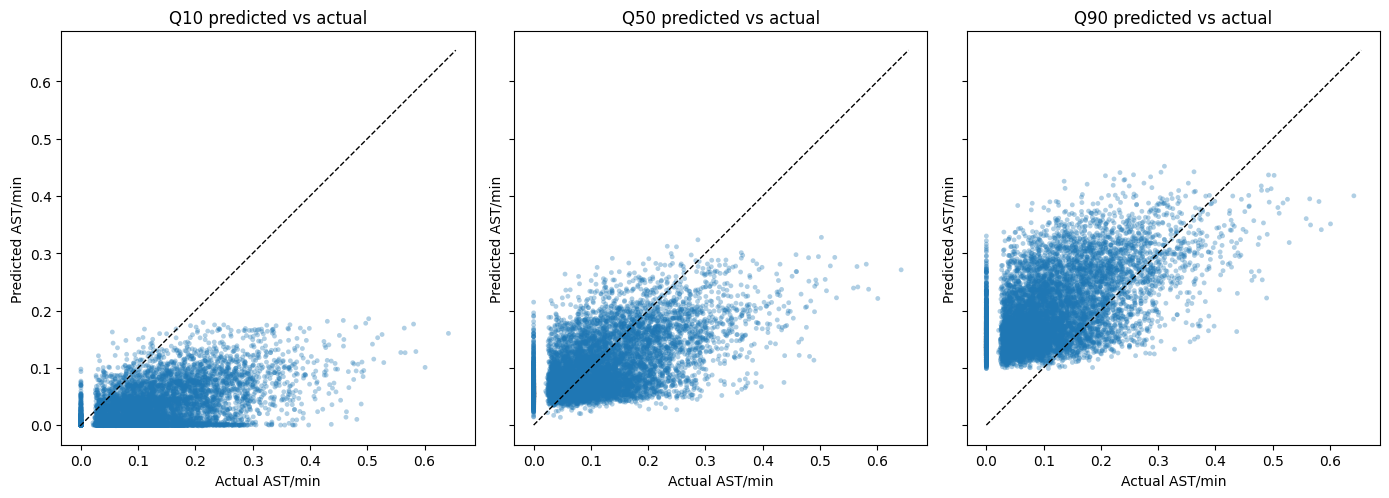

Q10 P(y ≤ pred): 0.1099836333878887
Q50 P(y ≤ pred): 0.49536279323513366
Q90 P(y ≤ pred): 0.8882705946535734
Coverage (10–90 interval): 77.83%


In [21]:
import matplotlib.pyplot as plt

y_true = y_val_f
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual AST/min")
    ax.set_ylabel("Predicted AST/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%


── q_0.10 ──


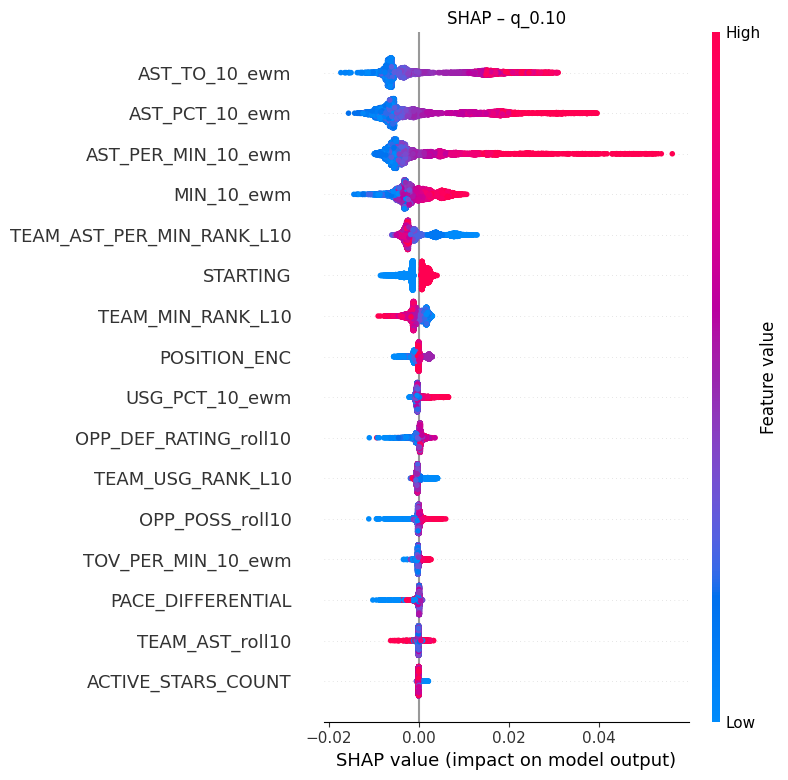


── q_0.50 ──


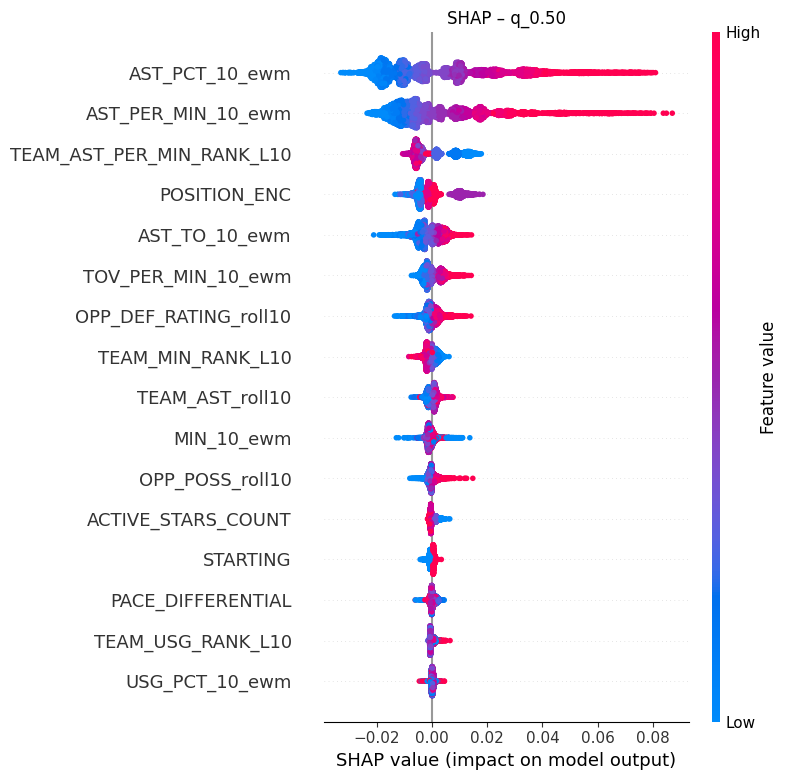


── q_0.90 ──


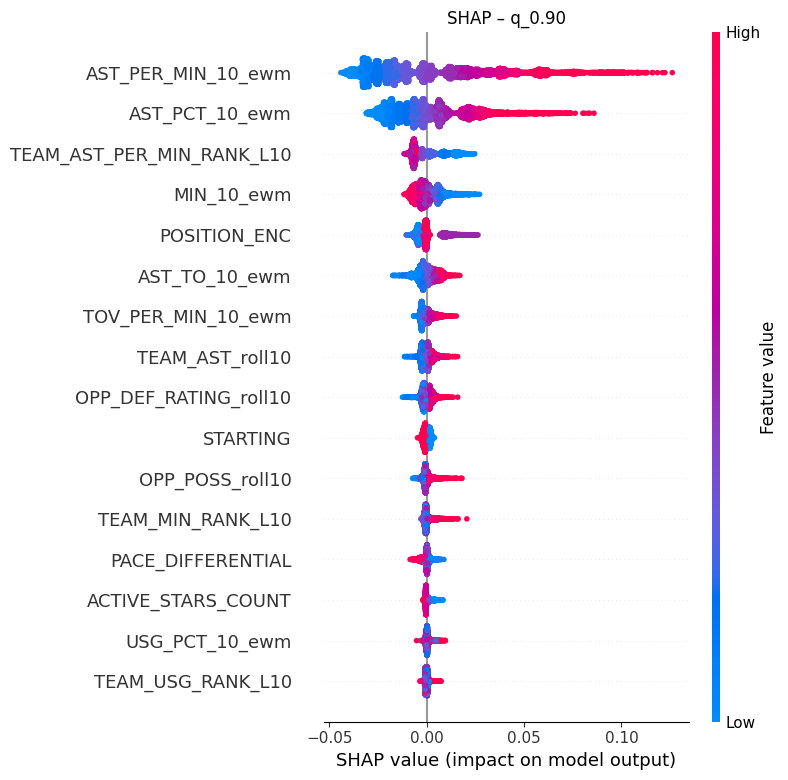

In [22]:
import shap

for q_key, model in quantile_models.items():
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_val_f)
    
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

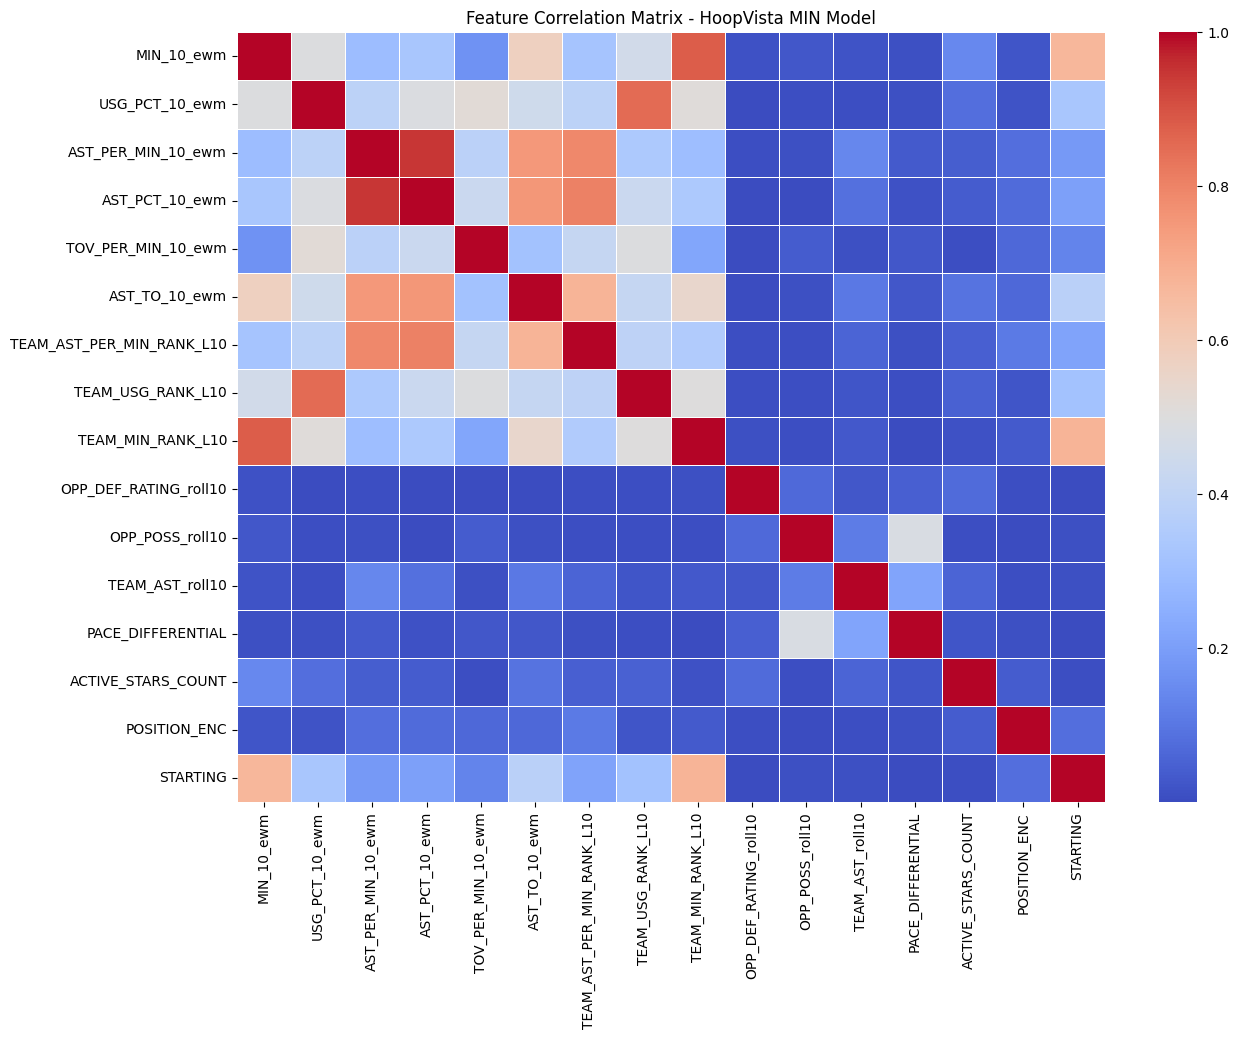

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [23]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, APM_FEATURES)
correlated_features

In [ ]:
import joblib
from pathlib import Path

# out_dir = Path("apm_quantile")  # or wherever you prefer
# out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "quantile_models": quantile_models,
    "feature_names": APM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, "src/models/saved_models/apm_quantile_xgb.joblib")

['src/models/saved_models/apm_quantile_xgb.joblib']

In [5]:
date = pd.Timestamp.now().normalize()  # midnight today, local tz
current_date = date.strftime("%Y-%m-%d")

# target_date = pd.Timestamp("2026-03-26")
# hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_assists')]
names = lines_dfs['NAME'].unique()
names

array(['Jalen Brunson', 'Mikal Bridges', 'Derrick White',
       'Payton Pritchard', 'Ousmane Dieng', 'Ace Bailey', 'Reed Sheppard',
       'Cody Williams', 'Scottie Barnes', 'Brandon Ingram',
       'DeMar DeRozan', 'Derik Queen', 'Devin Vassell', 'Aaron Gordon'],
      dtype=object)

In [6]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

apm_bundle = joblib.load("src/models/saved_models/apm_quantile_xgb.joblib")
apm_quantile_models = apm_bundle["quantile_models"]
apm_feature_names = apm_bundle["feature_names"]



KeyError: 'scaler'

## MIN + APM (ANALYSIS)

In [7]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name, current_date)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        apm_feats = apm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(apm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(apm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(apm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(apm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_APM_Q10": p10,
            "PRED_APM_Q50": p50,
            "PRED_APM_Q90": p90,
            "PRED_AST_Q10": round(pts10, 2),
            "PRED_AST_Q50": round(pts50, 2),
            "PRED_AST_Q90": round(pts90, 2),
            "PRED_AST_RANGE_10_90": round(pts90 - pts10, 2),
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_APM_Q10": np.nan,
            "PRED_APM_Q50": np.nan,
            "PRED_APM_Q90": np.nan,
            "PRED_AST_Q10": np.nan,
            "PRED_AST_Q50": np.nan,
            "PRED_AST_Q90": np.nan,
            "PRED_AST_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] Jalen Brunson: name 'apm_quantile_models' is not defined
[SKIP] Mikal Bridges: name 'apm_quantile_models' is not defined
[SKIP] Derrick White: name 'apm_quantile_models' is not defined
[SKIP] Payton Pritchard: name 'apm_quantile_models' is not defined
[SKIP] Ousmane Dieng: name 'apm_quantile_models' is not defined
[SKIP] Ace Bailey: name 'apm_quantile_models' is not defined
[SKIP] Reed Sheppard: name 'apm_quantile_models' is not defined
[SKIP] Cody Williams: name 'apm_quantile_models' is not defined
[SKIP] Scottie Barnes: name 'apm_quantile_models' is not defined
[SKIP] Brandon Ingram: name 'apm_quantile_models' is not defined
[SKIP] DeMar DeRozan: name 'apm_quantile_models' is not defined
[SKIP] Derik Queen: name 'apm_quantile_models' is not defined
[SKIP] Devin Vassell: name 'apm_quantile_models' is not defined
[SKIP] Aaron Gordon: name 'apm_quantile_models' is not defined


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_APM_Q10,PRED_APM_Q50,PRED_APM_Q90,PRED_AST_Q10,PRED_AST_Q50,PRED_AST_Q90,PRED_AST_RANGE_10_90
0,Jalen Brunson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mikal Bridges,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Derrick White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Payton Pritchard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ousmane Dieng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. THE CORE SIMULATION ENGINE (POISSON-BASED)
# ---------------------------------------------------------

def triangular_clip(row, q10, q50, q90, lo_scale=0.70, hi_scale=1.30, low=0.0, high=np.inf, n_sims=10_000):
    """
    Generates a triangular distribution based on XGBoost quantiles.
    Widening the scales (lo_scale, hi_scale) introduces 'NBA Chaos' (fouls, blowouts).
    """
    mode = float(row[q50])
    # Ensure left < mode < right
    left = min(float(row[q10]) * lo_scale, mode - 0.001)
    right = max(float(row[q90]) * hi_scale, mode + 0.001)
    
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.full(n_sims, mode if np.isfinite(mode) else 0.0)
    
    # Generate continuous samples
    samples = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(samples, low, high)

def run_stat_simulation(row, stat_prefix="APM", n_sims=10_000):
    """
    Paired simulation: Minutes * Rate.
    Converts expected continuous value into discrete integers using Poisson.
    """
    # Simulate Minutes
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.75, hi_scale=1.25, low=0, high=48, n_sims=n_sims,
    )
    
    # Simulate Rate (APM or RPM)
    sim_rate = triangular_clip(
        row,
        f"PRED_{stat_prefix}_Q10", f"PRED_{stat_prefix}_Q50", f"PRED_{stat_prefix}_Q90",
        lo_scale=0.70, hi_scale=1.30, low=0, high=np.inf, n_sims=n_sims,
    )
    
    # Calculate Lambda (Expected value for each sim)
    expected_val = sim_min * sim_rate
    
    # Poisson Sampling: The 'Counting' Step
    # This turns 7.4 expected rebounds into a distribution of 6, 7, 8, 9...
    sim_counts = np.random.poisson(lam=expected_val)
    
    return sim_counts

# ---------------------------------------------------------
# 2. LINE LOOKUP & MAPPING
# ---------------------------------------------------------

def _line_lookup_from_lines_df(ldf: pd.DataFrame, name_dict: dict) -> dict:
    """
    Maps sportsbook names to canonical dataset names.
    Handles 'Jokic' vs 'Jokić' logic.
    """
    d = {}
    for _, r in ldf.iterrows():
        book_name = str(r["NAME"]).strip()
        line = r["LINE"]
        d[book_name] = line
        
        # Add the canonical version if it exists in your nameDict
        canon = name_dict.get(book_name)
        if canon:
            d[canon] = line
            
    # Reverse check: ensure variants point to the line if canon was found
    for variant, canon in name_dict.items():
        if canon in d and variant not in d:
            d[variant] = d[canon]
    return d

# ---------------------------------------------------------
# 3. EXECUTION LOOP
# ---------------------------------------------------------

# Build the lookup
line_by_name = _line_lookup_from_lines_df(lines_dfs, nameDict)

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)
    
    # Validation
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({
            "PLAYER_NAME": name, "LINE": np.nan, 
            "P_OVER": np.nan, "P_UNDER": np.nan, "P_PUSH": np.nan
        })
        continue

    # Run the Poisson Simulation (Change prefix to 'APM' for Assists)
    stat_sims = run_stat_simulation(row, stat_prefix="APM", n_sims=10_000)
    line = float(line)
    
    # Calculate Integer-Aware Probabilities
    p_over = float(np.mean(stat_sims > line))
    p_under = float(np.mean(stat_sims < line))
    p_push = float(np.mean(stat_sims == line))

    # Calculate Edge and EV
    # Assuming -119 odds (~1.84x payout) for Underdog standard
    # EV = (P_win * Profit) - (P_loss * Stake)
    # Simplified here for relative ranking:
    edge = row["PRED_AST_Q50"] - line 
    
    results.append({
        "PLAYER_NAME": name,
        "LINE": line,
        "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
        "PRED_STAT_Q50": round(row["PRED_AST_Q50"], 2),
        "P_OVER": round(p_over, 3), 
        "P_UNDER": round(p_under, 3),
        "P_PUSH": round(p_push, 3),
        "EDGE": round(edge, 2),
        "EV": round((p_over * 10) - (p_under * 10), 2) # Weighted directional EV
    })

# Create final DataFrame
line_probs_df = pd.DataFrame(results)

# Sort by absolute edge to find the biggest discrepancies
line_probs_df['ABS_EDGE'] = line_probs_df['EDGE'].abs()
line_probs_df = line_probs_df.sort_values(by="ABS_EDGE", ascending=False)

# Display top plays
print(line_probs_df[['PLAYER_NAME', 'LINE', 'PRED_STAT_Q50', 'P_OVER', 'P_UNDER', 'P_PUSH', 'EDGE']].head(15))

         PLAYER_NAME  LINE  PRED_STAT_Q50  P_OVER  P_UNDER  P_PUSH  EDGE
8     Scottie Barnes   8.5           7.28   0.417    0.583     0.0 -1.22
5         Ace Bailey   2.5           1.59   0.375    0.625     0.0 -0.91
6      Reed Sheppard   4.5           3.78   0.457    0.543     0.0 -0.72
7      Cody Williams   3.5           2.78   0.403    0.597     0.0 -0.72
3   Payton Pritchard   4.5           3.79   0.422    0.578     0.0 -0.71
10     DeMar DeRozan   4.5           5.18   0.646    0.354     0.0  0.68
4      Ousmane Dieng   4.5           3.96   0.463    0.537     0.0 -0.54
9     Brandon Ingram   3.5           3.99   0.669    0.331     0.0  0.49
13      Aaron Gordon   2.5           2.88   0.680    0.320     0.0  0.38
12     Devin Vassell   2.5           2.83   0.691    0.309     0.0  0.33
0      Jalen Brunson   7.5           7.26   0.524    0.476     0.0 -0.24
1      Mikal Bridges   3.5           3.34   0.581    0.419     0.0 -0.16
2      Derrick White   4.5           4.66   0.603  